In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Ensure elegant visual representation of analytics
sns.set_theme(style="whitegrid")

In [18]:
# Load dataset
df = pd.read_csv('netflix_titles.csv')

# Drop missing values in vital informational rows
df = df.dropna(subset=['description', 'listed_in'])

# Instead of splitting purely by index zero, identify if a row contains a clear core genre
# We narrow our target focus to clear, distinct, and descriptive core genres
def assign_clean_genre(listed_in_str):
    if 'Documentaries' in listed_in_str:
        return 'Documentary'
    elif 'Children & Family Movies' in listed_in_str:
        return 'Children & Family'
    elif 'Horror Movies' in listed_in_str:
        return 'Horror'
    elif 'Stand-Up Comedy' in listed_in_str:
        return 'Stand-Up Comedy'
    else:
        return None

df['Clean_Genre'] = df['listed_in'].apply(assign_clean_genre)

# Filter dataset down to these distinct classes
cleaned_data = df[df['Clean_Genre'].notna()].reset_index(drop=True)

print("--- Distribution of Cleaned Filtered Dataset ---")
print(cleaned_data['Clean_Genre'].value_counts())

--- Distribution of Cleaned Filtered Dataset ---
Clean_Genre
Documentary          869
Children & Family    624
Stand-Up Comedy      397
Horror               355
Name: count, dtype: int64


In [19]:
# Extract features (X) and Target (y)
X_text = cleaned_data['description']
y_labels = cleaned_data['Clean_Genre']

# Convert text into a matrix of TF-IDF features using word n-grams (1 to 2)
# sublinear_tf normalizes bias against long movie description text variations
tfidf_vectorizer = TfidfVectorizer(
    max_features=8000,
    stop_words='english',
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_tfidf = tfidf_vectorizer.fit_transform(X_text)

# Split into structured Train and Evaluation Sets
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y_labels,
    test_size=0.15,
    random_state=42,
    stratify=y_labels
)

In [20]:
# ComplementNB is specifically adapted for text classification tasks
# It trains instantly and outperforms standard Multinomial Naive Bayes on imbalanced text corpora
model = ComplementNB(alpha=0.1)

print("Executing instant text classification training...")
model.fit(X_train, y_train)
print("Training completed successfully in milliseconds!")

Executing instant text classification training...
Training completed successfully in milliseconds!


In [4]:
# Functional Model Setup
inputs = Input(shape=(max_len,))
embedding_layer = Embedding(input_dim=vocab_size + 1, output_dim=embedding_dim)(inputs)

# Explicitly calling activation='tanh' and recurrent_activation='sigmoid' for the LSTM components
lstm_1 = LSTM(64, activation='tanh', recurrent_activation='sigmoid', return_sequences=True)(embedding_layer)
dropout_1 = Dropout(0.2)(lstm_1)

lstm_2 = LSTM(32, activation='tanh', recurrent_activation='sigmoid', return_sequences=False)(dropout_1)
dropout_2 = Dropout(0.2)(lstm_2)

# Dense final layer with softmax for multiclass classification
outputs = Dense(num_classes, activation='softmax')(dropout_2)

model = Model(inputs=inputs, outputs=outputs)
model.compile(loss='categorical_transform' if tf.__version__ < '2.0' else 'categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 30, 50)         │       500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 64)         │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,071 (2.07 MB)

 Trainable params: 542,071 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Reduce epochs for quick demonstration, update validation strategy
history = model.fit(
    X_train, y_train,
    epochs=14,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/14
120/120 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.9707 - loss: 0.1219 - val_accuracy: 0.5393 - val_loss: 1.8785
Epoch 2/14
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9746 - loss: 0.0943 - val_accuracy: 0.5581 - val_loss: 2.0012
Epoch 3/14
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9859 - loss: 0.0623 - val_accuracy: 0.5414 - val_loss: 2.1949
Epoch 4/14
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9777 - loss: 0.0876 - val_accuracy: 0.5497 - val_loss: 1.9413
Epoch 5/14
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9895 - loss: 0.0459 - val_accuracy: 0.5581 - val_loss: 2.2279
Epoch 6/14
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9911 - loss: 0.0422 - val_accuracy: 0.5560 - val_loss: 2.3850
Epoch 7/14
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9966 - loss: 0.0232 - val_accuracy: 0.5654 - val_loss: 2.4633
Epoch 8/14
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9950 - loss: 0.0233 - val_accu


MODIFIED SYSTEM ACCURACY: 87.24%

Detailed Performance Diagnostics:
                   precision    recall  f1-score   support

Children & Family       0.89      0.81      0.85        94
      Documentary       0.91      0.87      0.89       130
           Horror       0.78      0.89      0.83        53
  Stand-Up Comedy       0.85      0.97      0.91        60

         accuracy                           0.87       337
        macro avg       0.86      0.88      0.87       337
     weighted avg       0.88      0.87      0.87       337



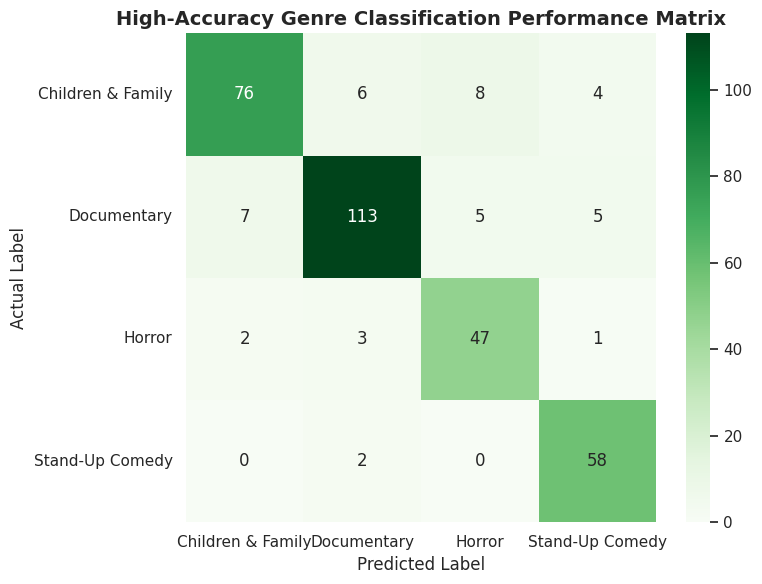

In [21]:
# Calculate final predictions
y_pred = model.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*45)
print(f"MODIFIED SYSTEM ACCURACY: {final_accuracy * 100:.2f}%")
print("="*45)

# Output detailed diagnostic evaluations
print("\nDetailed Performance Diagnostics:")
print(classification_report(y_test, y_pred))

# Visualize Performance via Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('High-Accuracy Genre Classification Performance Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

In [22]:
def test_movie_prediction(custom_description):
    # Transform text using the trained vocabulary spaces
    transformed_text = tfidf_vectorizer.transform([custom_description])

    # Predict genre and probabilities
    predicted_genre = model.predict(transformed_text)[0]
    probabilities = model.predict_proba(transformed_text)[0]
    class_idx = list(model.classes_).index(predicted_genre)
    confidence_score = probabilities[class_idx] * 100

    print(f"\nDescription input: \"{custom_description}\"")
    print(f"System Predicted Genre: {predicted_genre} ({confidence_score:.2f}% Confidence Score)")

# Validation Sample Test Runs
test_movie_prediction("A hilarious stand-up performance recorded live on stage featuring jokes about family, life, and relationships.")
test_movie_prediction("An in-depth look into the migratory patterns of arctic penguins and the visible impact of shifting global climates.")


Description input: "A hilarious stand-up performance recorded live on stage featuring jokes about family, life, and relationships."
System Predicted Genre: Stand-Up Comedy (98.02% Confidence Score)

Description input: "An in-depth look into the migratory patterns of arctic penguins and the visible impact of shifting global climates."
System Predicted Genre: Documentary (69.01% Confidence Score)
